In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/gdrive


In [2]:
import pandas as pd
data=pd.read_csv("/content/gdrive/My Drive/p/p_features_399_Svr.csv")

In [3]:
data=data.drop(['Unnamed: 0'], axis = 1) 

In [4]:
print(data.head())

                                           svr_input              svr_values
0  [0.6126549778522289, 0.29623485998737614, 0.23...  [0.028896592000000002]
1  [0.6121893417930195, 0.29613176452378626, 0.23...           [0.028221725]
2  [0.6130110713538157, 0.29611125620053785, 0.23...           [0.027546857]
3  [0.6183914239245318, 0.296686781014481, 0.2339...  [0.029571458999999998]
4  [0.6144552985251677, 0.29611872639194786, 0.23...            [0.02687199]


In [5]:
print(data['svr_input'])

0        [0.6126549778522289, 0.29623485998737614, 0.23...
1        [0.6121893417930195, 0.29613176452378626, 0.23...
2        [0.6130110713538157, 0.29611125620053785, 0.23...
3        [0.6183914239245318, 0.296686781014481, 0.2339...
4        [0.6144552985251677, 0.29611872639194786, 0.23...
                               ...                        
25859    [0.5186052134992647, 0.0974757096544595, 0.355...
25860    [1.5640906474614207, 1.5784415349921395, 1.528...
25861    [0.7394948099235977, 0.42310281573157804, 0.19...
25862    [0.40297602702238516, 0.4312947955195295, 1.18...
25863    [0.605235650702448, 0.5222939478545613, 0.4687...
Name: svr_input, Length: 25864, dtype: object


In [6]:
svrinput=[]
def Convert(string): 
    li = list(string.split(",")) 
    return li 
     
for i in range(len(data['svr_input'])):
   str1 = data['svr_input'][i][1:-1]
   nums = list(map(float, Convert(str1)))

   svrinput.append(nums)
   str1=""
   nums=list()
print(len(svrinput))  

25864


In [7]:
df1=pd.DataFrame(svrinput)

In [8]:
df2=pd.read_csv('/content/phoscaled.csv', sep=',',header=None)

In [9]:
print(df2.keys())

Int64Index([0, 1, 2], dtype='int64')


In [10]:
svrvalues=[]
for i in range(len(data['svr_values'])):
    svrvalues.append(float(data['svr_values'][i][1:-1]))

df1['y']= svrvalues
df1['lat']=df2[0]
df1['long']=df2[1]

print(df1)

              0         1         2  ...         y        lat       long
0      0.612655  0.296235  0.233790  ...  0.028897  17.894722  73.401111
1      0.612189  0.296132  0.233731  ...  0.028222  17.894722  73.401389
2      0.613011  0.296111  0.233700  ...  0.027547  17.894722  73.402222
3      0.618391  0.296687  0.233971  ...  0.029571  17.894722  73.403056
4      0.614455  0.296119  0.233680  ...  0.026872  17.894722  73.403333
...         ...       ...       ...  ...       ...        ...        ...
25859  0.518605  0.097476  0.355535  ...  0.018804  20.596389  75.147778
25860  1.564091  1.578442  1.528745  ...  0.080217  20.596667  74.475000
25861  0.739495  0.423103  0.190202  ...  0.091260  20.596667  75.914167
25862  0.402976  0.431295  1.183188  ...  0.085309  20.598056  75.423056
25863  0.605236  0.522294  0.468705  ...  0.091230  20.598056  75.595278

[25864 rows x 403 columns]


In [11]:
x=df1.drop(['y'], axis = 1).values
y= df1.y.values.reshape(-1,1)

In [12]:
print(x)

[[6.12654978e-01 2.96234860e-01 2.33790095e-01 ... 1.20506457e-01
  1.78947222e+01 7.34011111e+01]
 [6.12189342e-01 2.96131765e-01 2.33730782e-01 ... 1.20543815e-01
  1.78947222e+01 7.34013889e+01]
 [6.13011071e-01 2.96111256e-01 2.33700269e-01 ... 1.20675517e-01
  1.78947222e+01 7.34022222e+01]
 ...
 [7.39494810e-01 4.23102816e-01 1.90202127e-01 ... 1.09139332e-01
  2.05966667e+01 7.59141667e+01]
 [4.02976027e-01 4.31294796e-01 1.18318849e+00 ... 1.17282155e-01
  2.05980556e+01 7.54230556e+01]
 [6.05235651e-01 5.22293948e-01 4.68704765e-01 ... 6.53282997e-02
  2.05980556e+01 7.55952778e+01]]


In [13]:
print(y)

[[0.02889659]
 [0.02822172]
 [0.02754686]
 ...
 [0.09126047]
 [0.08530936]
 [0.09122979]]


In [14]:
from scipy.spatial import distance
from collections import OrderedDict 
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
print(len(x_train[0]))


402


/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [18]:
X_train=[]
for i in range(len(x_train)):
   X_train.append(x_train[i][:-2])
print(len(X_train[0]))

400


In [19]:
X_test=[]
for i in range(len(x_test)):
   X_test.append(x_test[i][:-2])
print(len(X_test[0]))

400


In [20]:
svr_rbf = SVR(kernel='linear', C=1, gamma=0.1, epsilon=.1)
svr_rbf.fit( X_train,y_train.ravel())

SVR(C=1, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma=0.1,
    kernel='linear', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

In [21]:
y_pred=svr_rbf.predict(X_test)
print(y_pred)

[0.12516539 0.03010027 0.04161212 ... 0.08555633 0.04256298 0.1795006 ]


In [22]:
print(len(y_pred))

5173


In [23]:
print(y_test)
output =[]
for i in range(len(y_test)):
  output.append(y_test[i][0])
print(output)

[[0.2307126 ]
 [0.04214853]
 [0.02895794]
 ...
 [0.01592073]
 [0.04076812]
 [0.10027915]]
[0.230712599, 0.042148532, 0.028957942999999996, 0.026411853, 0.027792264, 0.009233412, 0.117212184, 0.021933188, 0.073591214, 0.019264395, 0.019233719, 0.035553238, 0.027424154, 0.020276696, 0.31102181, 0.016595601, 0.020031289, 0.040798798, 0.050430995, 0.017761281, 0.053406546, 0.024509954, 0.042271235, 0.027546857, 0.046719225, 0.04107488, 0.025000767, 0.024816712, 0.018620203000000002, 0.049050584, 0.022485352000000004, 0.200619651, 0.046504494, 0.019356421999999998, 0.037853922000000005, 0.036780269, 0.006441915, 0.000153379, 0.0038037979999999997, 0.035093101, 0.024786036, 0.021810485, 0.003220958, 0.017945336, 0.160495721, 0.018068038999999998, 0.031319979, 0.056382098, 0.020031289, 0.015736679, 0.031043897, 0.027792264, 0.003957177, 0.031135924, 0.084573146, 0.016411546000000003, 0.016902359, 0.013712077, 0.085309365, 0.014601675, 0.043528943, 0.011595448000000001, 0.036780269, 0.02322157

In [26]:
svrresults={'lat':[],'long':[],'actual':[],'predicted':[]}
for i in range(len(x_test)):
    svrresults['lat'].append(x_test[i][-2])
    svrresults['long'].append(x_test[i][-1])
svrresults['actual']=output
svrresults['predicted']=y_pred
print(svrresults['lat'])
log_df = pd.DataFrame(svrresults)
log_df.to_csv('/content/gdrive/My Drive/p/p_400_final_results.csv')

[19.20833333, 18.20666667, 18.395, 18.28638889, 19.26555556, 18.89388889, 19.61777778, 18.58583333, 18.89638889, 18.28555556, 18.42527778, 18.46944444, 19.77277778, 18.92916667, 19.17888889, 18.80694444, 20.48555556, 19.63805556, 19.55416667, 18.22444444, 19.00972222, 18.2025, 19.78083333, 19.09444444, 19.425, 18.42027778, 18.18138889, 19.62166667, 18.26305556, 18.45861111, 18.47111111, 20.21861111, 18.38472222, 18.29472222, 18.06861111, 19.02361111, 18.37944444, 18.35777778, 18.33888889, 19.39666667, 18.48111111, 18.55972222, 18.37888889, 18.80666667, 19.39472222, 18.27194444, 17.98138889, 19.60638889, 19.17666667, 18.36527778, 18.2975, 18.49944444, 18.32222222, 19.46166667, 19.18027778, 18.57972222, 18.37416667, 19.3925, 19.86361111, 19.77583333, 18.46, 18.3975, 18.27166667, 18.51444444, 19.06083333, 18.03055556, 18.19027778, 18.60555556, 17.97861111, 18.37694444, 17.96638889, 18.15833333, 18.41777778, 19.11027778, 17.99444444, 18.25805556, 18.22333333, 18.32555556, 19.80055556, 19.0

In [27]:
def smape(A, F):
    return 1/len(A) * np.sum(2 * np.abs(F - A) / (np.abs(A) + np.abs(F)))
def manualr2(A,F):
  correlation_matrix = np.corrcoef(A,F)
  correlation_xy = correlation_matrix[0,1]
  r_squared = correlation_xy**2
  return r_squared 
print(y_test)
print(y_pred)


[[0.2307126 ]
 [0.04214853]
 [0.02895794]
 ...
 [0.01592073]
 [0.04076812]
 [0.10027915]]
[0.12516539 0.03010027 0.04161212 ... 0.08555633 0.04256298 0.1795006 ]


Int64Index([3, 4], dtype='int64')


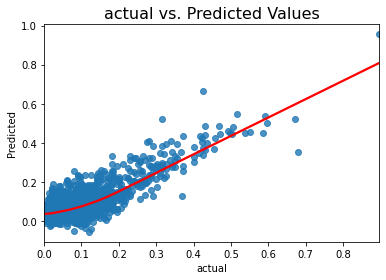

In [28]:
from sklearn import datasets
from sklearn.model_selection import cross_val_predict
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df1=pd.read_csv('/content/gdrive/My Drive/p/p_400_final_results.csv', sep=',',header=None)
df1=df1.drop([0,1,2],axis=1)
df1=df1.drop([0],axis=0)
df1.head()
print(df1.keys())
fig, ax = plt.subplots(1,1)
sns.regplot(x=list(map(float, df1[3])) , y=list(map(float, df1[4])) , lowess=True, ax=ax, line_kws={'color': 'red'})
ax.set_title('actual vs. Predicted Values', fontsize=16)
ax.set(ylabel='Predicted', xlabel='actual')
def mape(row):
    return abs(row.Forecast - row.Actual) / ((abs(row.Actual) + abs(row.Forecast))/2)

# create the pandas dataframe if you dont have one already
df=pd.DataFrame.from_dict({'Actual':list(map(float, df1[3])), 'Forecast':list(map(float, df1[4]))})

# apply the above function on each row 
smape = df.apply(mape, axis=1).sum() * (1/len(df))


In [30]:
val_dict = dict()
val_dict['rmse']=[]
val_dict['r2']=[]
val_dict['manualr2']=[]
val_dict['smape']=[]
val_dict['mae']=[]
rmse_list =[]
r2_list =[]
mae_list =[]
smape_list =[]
rmse_list.append( sqrt(mean_squared_error(y_pred ,output )))
# smape_list.append(smape(y_pred , output ))
r2_list.append(r2_score(y_pred , output ))
mae_list.append(mean_absolute_error(y_pred , output ))

val_dict['rmse'].append(rmse_list)
val_dict['r2'].append(svr_rbf.score(X_test, output))
val_dict['manualr2'].append(manualr2(y_pred,output))
val_dict['mae'].append(mae_list)
val_dict['smape'].append(smape)
log_df = pd.DataFrame(val_dict)
log_df.to_csv('/content/gdrive/My Drive/p/p_val_r.csv')
